# Notebook 02: カーブダイナミクス

**目的**: イールドカーブの「形の変化」を、**動き(ダイナミクス)** の側面から目で理解する。

## やること
1. **月次スナップショット**を重ね描き(時間軸での「形の変化」を絵で見る)
2. **日次変化(差分)を bp 単位**で計算・可視化
3. **スロープ指標**を複数定義(2s10s / 5s30s)し、比較する
4. **ベア/ブル × スティープ/フラット 4分類**を導入し、各日を分類する

## チェックポイント
- [ ] カーブが「右肩上がりが普通だが、形が日々違う」ことを目視確認
- [ ] 1日の動きが大体 ±10bp の範囲に収まることを確認
- [ ] 2022〜2024年あたりで Slope がマイナス(逆イールド)になったことを確認

## この Notebook で導入される金融用語
- 順イールド / 逆イールド
- ベアマーケット / ブルマーケット(債券)
- スティープナー / フラットナー
- スプレッドトレード(2s10s フラットナー等)

## 0. セットアップとデータ読み込み

Notebook 01 で保存した parquet をロード。**取得をやり直さない**(再現性・速度のため)。

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# パスとプロット設定
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# 年限を年単位の数値に(プロットで横軸として使う)
MATURITY_YEARS = {
    "3M": 0.25, "6M": 0.5, "1Y": 1, "2Y": 2, "3Y": 3,
    "5Y": 5, "7Y": 7, "10Y": 10, "20Y": 20, "30Y": 30,
}

# データ読み込み
yields = pd.read_parquet(DATA_PROCESSED / "ust_yields_clean.parquet")
print(f"Shape: {yields.shape}")
print(f"Date range: {yields.index.min().date()} to {yields.index.max().date()}")
yields.head()

Shape: (1580, 10)
Date range: 2020-01-02 to 2026-04-27


maturity,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,
2020-01-02,1.54,1.57,1.56,1.58,1.59,1.67,1.79,1.88,2.19,2.33
2020-01-03,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26
2020-01-06,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28
2020-01-07,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31
2020-01-08,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35


## 1. 月次スナップショット — カーブの「形の変化」を一望する

1500本以上の日次カーブを全部重ねると見えなくなるので、**月末1本** に間引いて重ね描きする。
色を**時間順のグラデーション(viridis)** にすることで、初期(青)→ 最近(黄)の流れが追える。

これは金利アナリストが日常的に見ているチャートの一つ。

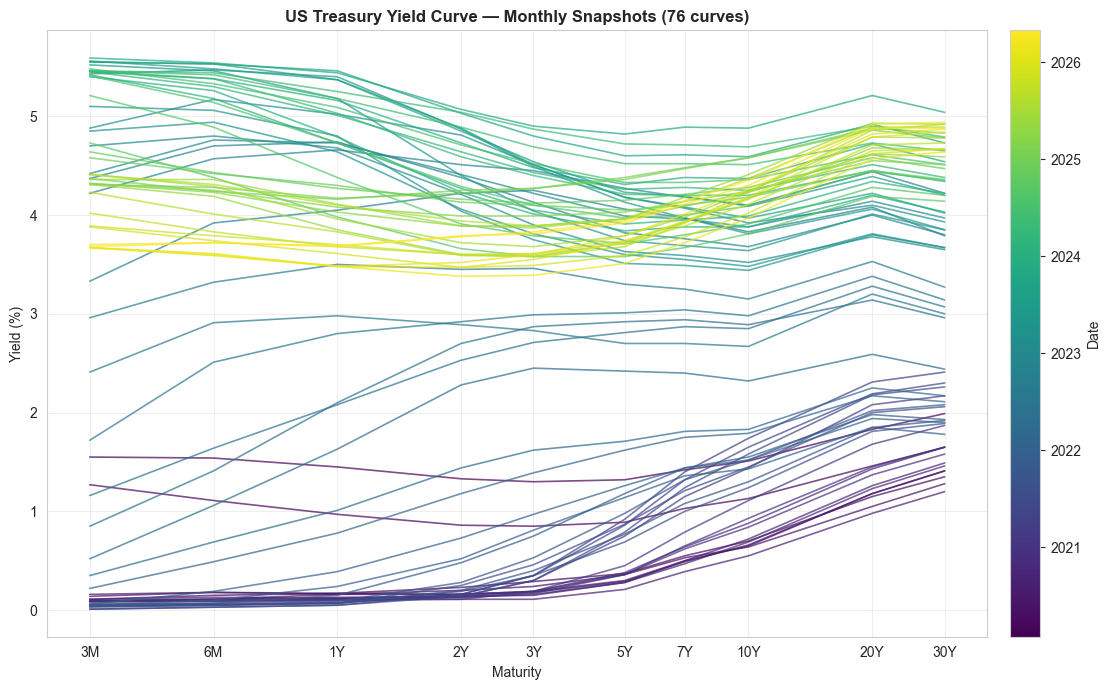

In [2]:
# 月末値を抽出
monthly = yields.resample("ME").last()
x_axis = np.array([MATURITY_YEARS[c] for c in yields.columns])

fig, ax = plt.subplots(figsize=(12, 7))

# viridis カラーマップで時間順に色付け
cmap = plt.get_cmap("viridis")
n = len(monthly)
for i, (date, row) in enumerate(monthly.iterrows()):
    color = cmap(i / max(n - 1, 1))
    ax.plot(x_axis, row.values, color=color, lw=1.2, alpha=0.7)

# カラーバーで「色 = 時間」を凡例化
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=mdates.date2num(monthly.index.min()),
                       vmax=mdates.date2num(monthly.index.max())),
)
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.ax.yaxis.set_major_locator(mdates.YearLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
cbar.set_label("Date")

ax.set_xscale("log")
ax.set_xticks(x_axis)
ax.set_xticklabels(yields.columns)
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
ax.set_title(f"US Treasury Yield Curve — Monthly Snapshots ({n} curves)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_monthly_snapshots.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 青(2020年): 全カーブが**1〜2%台**にある(コロナ・ゼロ金利時代)
- 緑〜黄緑(2022〜2023年): カーブが**5%付近まで上方シフト**(FRB急速利上げ)
- 黄緑〜黄(2023〜2024年): **短期が長期を上回り、形が逆向き**(逆イールド期)
- 黄(2025〜2026年): **再び右肩上がりに戻る**(利下げ転換でカーブ正常化)

→ **「カーブの全体的な水準(Level)」と「形(Slope/Curvature)」は別々に動く**ことが目で見える。
これが PCA で 3軸に分解する動機になる。

## 2. 日次変化(差分)を bp 単位で見る

PCA は水準ではなく**変化**にかける(理由は前回の議論参照: 水準は非定常)。
なので、ここで日次変化を計算し、**bp 単位**に変換する。

```
1 bp = 0.01% = 0.0001
→ %表記の値を 100倍 で bp になる
```

業界標準として「日次変化は bp で語る」ので、ここで単位変換しておく。

In [3]:
# %表記なので 100倍で bp
changes_bp = yields.diff().dropna() * 100
changes_bp.columns.name = "maturity"

print(f"Shape: {changes_bp.shape}  (1日減るのは diff() のため)")
print(f"\n単位: bp (1bp = 0.01%)")
changes_bp.head().round(1)

Shape: (1579, 10)  (1日減るのは diff() のため)

単位: bp (1bp = 0.01%)


maturity,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,
2020-01-03,-2.0,-2.0,-1.0,-5.0,-5.0,-8.0,-8.0,-8.0,-8.0,-7.0
2020-01-06,4.0,1.0,-1.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0
2020-01-07,-2.0,0.0,-1.0,0.0,-1.0,1.0,2.0,2.0,3.0,3.0
2020-01-08,0.0,0.0,2.0,4.0,6.0,5.0,4.0,4.0,5.0,4.0
2020-01-09,0.0,0.0,-1.0,0.0,-2.0,-2.0,-1.0,-2.0,-4.0,3.0


### 2.1 統計でチェックポイントを検証

**仕様書のチェック**: 「1日の動きが大体 ±10bp の範囲に収まる」

In [4]:
# 5%、95%、絶対値の95%を計算
stats_table = pd.DataFrame({
    "std": changes_bp.std(),
    "5%ile": changes_bp.quantile(0.05),
    "95%ile": changes_bp.quantile(0.95),
    "|95%|ile": changes_bp.abs().quantile(0.95),
    "max abs": changes_bp.abs().max(),
}).round(1)

print("日次変化の分布(bp)")
print(stats_table)

within_10bp = (changes_bp.abs() <= 10).all(axis=1).mean() * 100
print(f"\n全年限が ±10bp 以内に収まる日の割合: {within_10bp:.1f}%")

日次変化の分布(bp)
          std  5%ile  95%ile  |95%|ile  max abs
maturity                                       
3M        3.5   -4.0     5.0       7.0     34.0
6M        3.6   -4.0     6.0       8.0     36.0
1Y        5.0   -7.0     7.0      10.0     60.0
2Y        6.2   -9.0    10.0      12.0     57.0
3Y        6.4  -10.0    10.0      14.0     43.0
5Y        6.4  -10.0    11.0      13.1     32.0
7Y        6.3  -10.0    10.0      13.0     31.0
10Y       6.0  -10.0    10.0      12.0     30.0
20Y       5.8   -9.0     9.0      12.0     35.0
30Y       5.7   -9.0     9.0      11.0     31.0

全年限が ±10bp 以内に収まる日の割合: 80.6%


**観察**:
- 標準偏差(std)は年限を問わず大体 **4〜7 bp/日**
- 95% の動きは ±10〜12 bp に収まっている → **仕様書のチェックポイント通り**
- ただし最大値(`max abs`)は ±50bp 超 → これらが**FOMC発表日や危機日**(後で個別に分析)

### 2.2 ヒートマップ — どの日にどの年限が動いたか

縦軸 = 日付、横軸 = 年限、色 = 日次変化(bp)。**赤 = 上昇、青 = 下落**。
イベントが**横一線**(全年限同方向)か**縦の偏り**(短期 or 長期だけ)かで動きの性格がわかる。

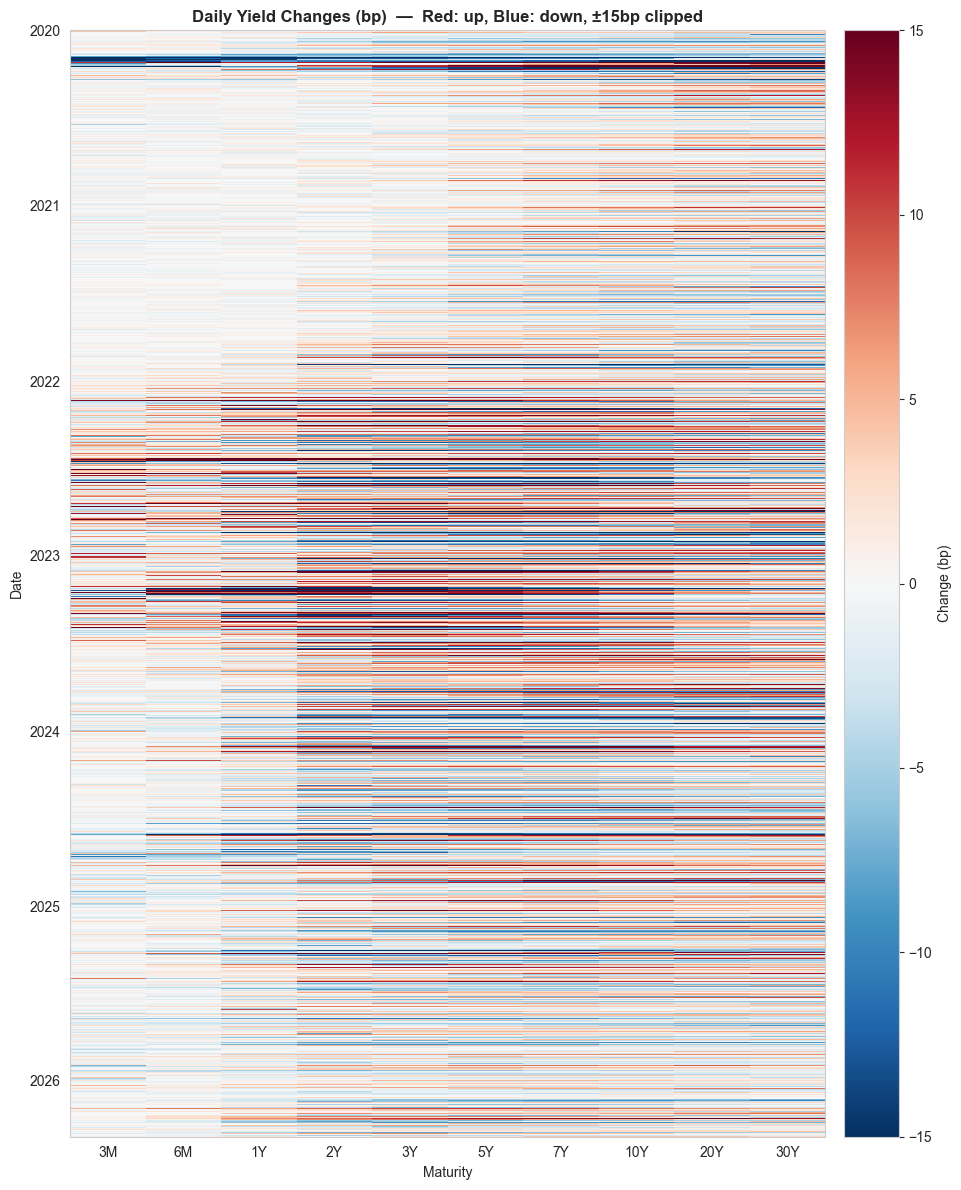

In [5]:
fig, ax = plt.subplots(figsize=(10, 12))

# 中央0を白、両端を赤・青に(diverging colormap)
vmax = 15  # ±15bpでクリップ。大きすぎる外れ値で全体が見えなくなるのを防ぐ
im = ax.pcolormesh(
    np.arange(len(yields.columns) + 1),
    np.arange(len(changes_bp) + 1),
    changes_bp.values,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    shading="auto",
)
ax.set_xticks(np.arange(len(yields.columns)) + 0.5)
ax.set_xticklabels(yields.columns)
ax.set_xlabel("Maturity")

# Y軸を年でラベル
year_starts = changes_bp.index.to_series().groupby(changes_bp.index.year).min()
year_idx = [changes_bp.index.get_loc(d) for d in year_starts]
ax.set_yticks(year_idx)
ax.set_yticklabels(year_starts.dt.year)
ax.set_ylabel("Date")
ax.invert_yaxis()  # 最新を上に

ax.set_title("Daily Yield Changes (bp)  —  Red: up, Blue: down, ±15bp clipped")
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Change (bp)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_changes_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- **2022年**: 短期(左側)が真っ赤 = 急速利上げで短期金利が連続上昇
- **2023年**: 全体的に変動が大きい(濃い色が頻発)
- **2024年9月以降**: 短期が**青く**(利下げ転換) ← ここが PC1↓ + PC2↑
- 横一線で同方向(全部赤 or 全部青)→ Level shift = PC1 が大きく動いた日
- 短期と長期で逆色 → Slope shift = PC2 が動いた日

### 2.3 年限ごとの動きの分布

「年限が違うとボラ(変動の大きさ)が違う」ことを確認。
**短期は政策金利に直結 → ステップ的、長期はインフレ期待 → スムース** という傾向がある。

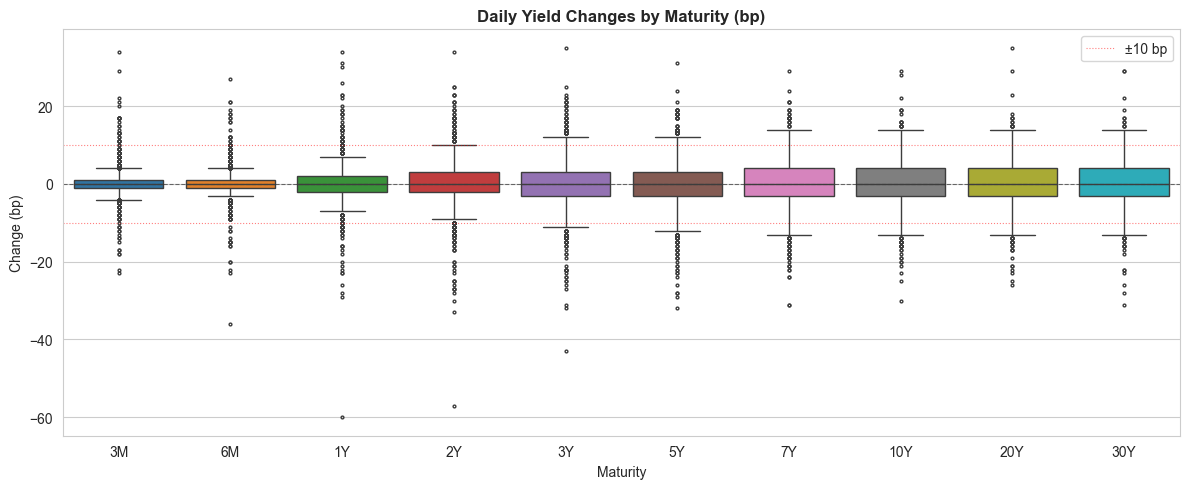

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=changes_bp, ax=ax, showfliers=True, fliersize=2)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.axhline(10, color="red", lw=0.8, ls=":", alpha=0.5, label="±10 bp")
ax.axhline(-10, color="red", lw=0.8, ls=":", alpha=0.5)
ax.set_title("Daily Yield Changes by Maturity (bp)")
ax.set_ylabel("Change (bp)")
ax.set_xlabel("Maturity")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_changes_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 中央値(箱の中の線)はどれも **0 付近** = 平均回帰している(これが PCA を使える前提)
- 箱(IQR)の高さは年限を問わず似ている = ボラ水準が近い → **標準化なしで PCA をかけて良い**(前回の議論)
- 外れ値(点)は短期(3M, 6M)に少なく、長期に多い傾向 → **長期はイベントに強く反応**

## 3. スロープ指標 — カーブの「傾き」を時系列で

「スロープ」は2つの年限の差として定義される。代表的なもの:

| 指標 | 定義 | 性格 |
|---|---|---|
| **2s10s** | 10y − 2y | 最も watch されている、景気サイクル指標 |
| **5s30s** | 30y − 5y | 長期側のスロープ、インフレ期待を強く反映 |
| **3M2Y** | 2y − 3M | 短期側、政策金利見通しを直接反映 |

PCA の **PC2 (Slope)** はこれらの一般化された指標になる。

C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:19: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:19: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:19: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:19: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:19: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_41052\3200098641.py:20: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from

C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36870 (\N{CJK UNIFIED IDEOGRAPH-9006}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


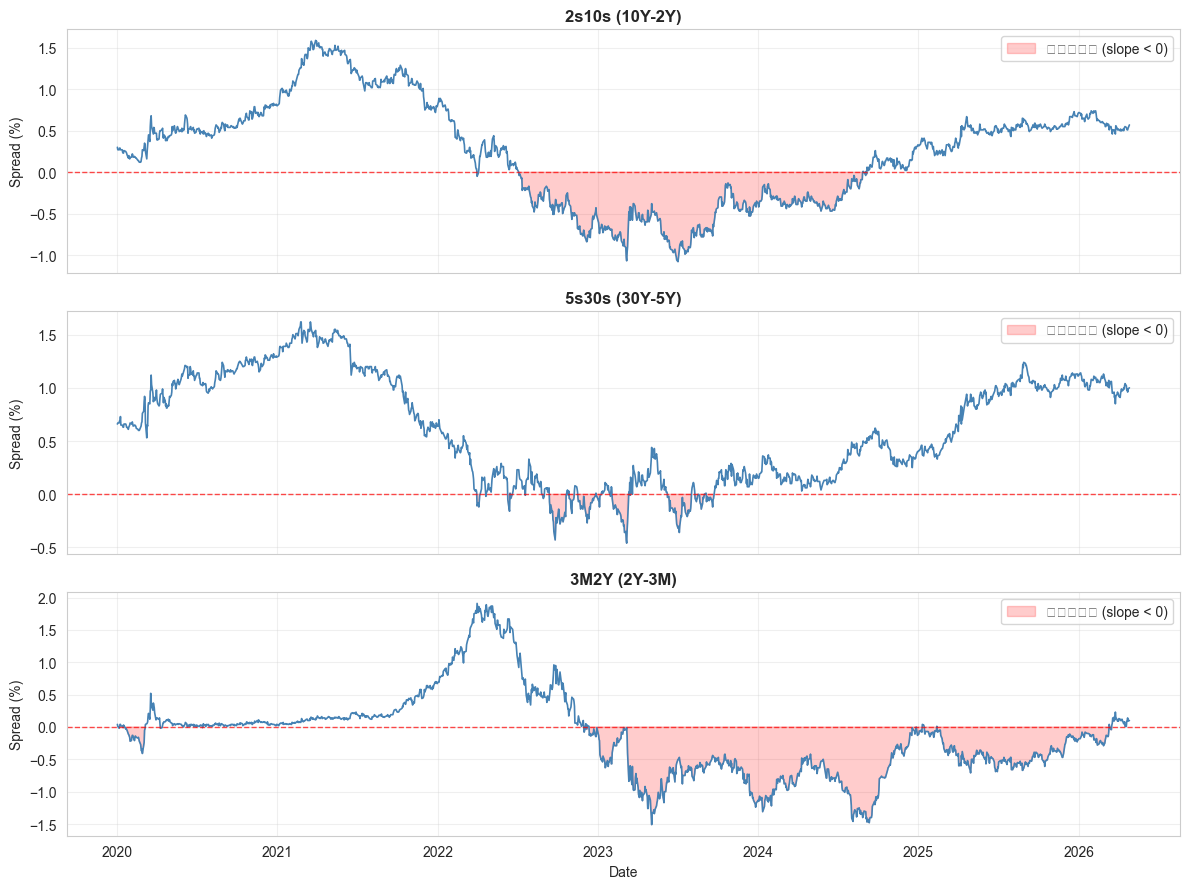

逆転(マイナス)日数:
  2s10s (10Y-2Y)         541 日 (34.2%)
  5s30s (30Y-5Y)         177 日 (11.2%)
  3M2Y (2Y-3M)           847 日 (53.6%)


In [7]:
slopes = pd.DataFrame({
    "2s10s (10Y-2Y)": yields["10Y"] - yields["2Y"],
    "5s30s (30Y-5Y)": yields["30Y"] - yields["5Y"],
    "3M2Y (2Y-3M)": yields["2Y"] - yields["3M"],
})

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col in zip(axes, slopes.columns):
    s = slopes[col]
    ax.plot(s.index, s.values, lw=1.2, color="steelblue")
    ax.axhline(0, color="red", ls="--", lw=1, alpha=0.7)
    ax.fill_between(s.index, s.values, 0, where=(s < 0),
                    color="red", alpha=0.2, label="逆イールド (slope < 0)")
    ax.set_title(col)
    ax.set_ylabel("Spread (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_slopes.png", dpi=120, bbox_inches="tight")
plt.show()

# 各スロープの逆転日数
print("逆転(マイナス)日数:")
for col in slopes.columns:
    n_neg = (slopes[col] < 0).sum()
    print(f"  {col:20s}  {n_neg:4d} 日 ({n_neg/len(slopes)*100:.1f}%)")

**観察**:
- **3M2Y は 2s10s より早く反転し、解消も早い** → 政策金利の見通し変化を最も鋭敏に反映
- **5s30s はマイナスにならない期間が多い** → 長期側は構造的に上向き(タームプレミアム)
- 3つの指標は同じ「Slope」の側面を違う粒度で捉えている → PCA の PC2 はこれらを最適に統合する

## 4. ベア/ブル × スティープ/フラット — 4分類

債券市場のジャーゴンで最も使われる**カーブの動きの分類**。仕組みは2軸の組み合わせ:

### 軸1: 全体水準の方向(Level)
- **ベア(Bear)** = **金利が上昇** = 債券価格は下落 → 債券保有者にとって弱気相場
- **ブル(Bull)** = **金利が下落** = 債券価格は上昇 → 強気相場

> ⚠️ 注意: 株式市場の「ブル/ベア」とは方向が逆(金利↑ = 価格↓ なので)

### 軸2: 傾きの変化(Slope)
- **スティープナー(Steepener)** = (10y − 2y) **拡大** = カーブが急になる
- **フラットナー(Flattener)** = (10y − 2y) **縮小** = カーブが平らになる

### 4分類の意味

| カテゴリ | 動き | 典型的な背景 |
|---|---|---|
| **Bear-Steepener** | 金利↑ かつ 長期↑↑ | インフレ警戒、長期インフレ期待上昇 |
| **Bear-Flattener** | 金利↑ かつ 短期↑↑ | FRB タカ派(利上げ加速、政策金利見通し上方修正) |
| **Bull-Steepener** | 金利↓ かつ 短期↓↓ | FRB ハト派(利下げ期待、景気減速) |
| **Bull-Flattener** | 金利↓ かつ 長期↓↓ | リセッション懸念、安全資産買い |

面接で「**FOMC でハト派発言があった日のカーブの動きは?**」と聞かれたら **Bull-Steepener** と即答できる。

In [8]:
# 各日のレベル変化(10Y を代表値とする)とスロープ変化
level_change = changes_bp["10Y"]
slope_change = changes_bp["10Y"] - changes_bp["2Y"]  # 2s10s の日次変化

regime = pd.Series(index=changes_bp.index, dtype="object")
regime[(level_change > 0) & (slope_change > 0)] = "Bear-Steepener"
regime[(level_change > 0) & (slope_change < 0)] = "Bear-Flattener"
regime[(level_change < 0) & (slope_change > 0)] = "Bull-Steepener"
regime[(level_change < 0) & (slope_change < 0)] = "Bull-Flattener"

# 配色: 直感的に — bear=warm, bull=cool;  steep=saturated, flat=muted
REGIME_COLORS = {
    "Bear-Steepener": "#d62728",   # 濃い赤
    "Bear-Flattener": "#ff9896",   # 薄い赤(オレンジ系)
    "Bull-Steepener": "#aec7e8",   # 薄い青
    "Bull-Flattener": "#1f77b4",   # 濃い青
}

regime_counts = regime.value_counts()
print("各レジームの日数:")
print(regime_counts)
print(f"\n全期間: {len(regime)} 日")

各レジームの日数:
Bear-Steepener    487
Bull-Flattener    484
Bear-Flattener    224
Bull-Steepener    192
Name: count, dtype: int64

全期間: 1579 日


### 4.1 4象限スキャッタープロット

横軸 = レベル変化(10Y bp)、縦軸 = スロープ変化(2s10s bp)。
**4象限がそのまま 4分類**になる。

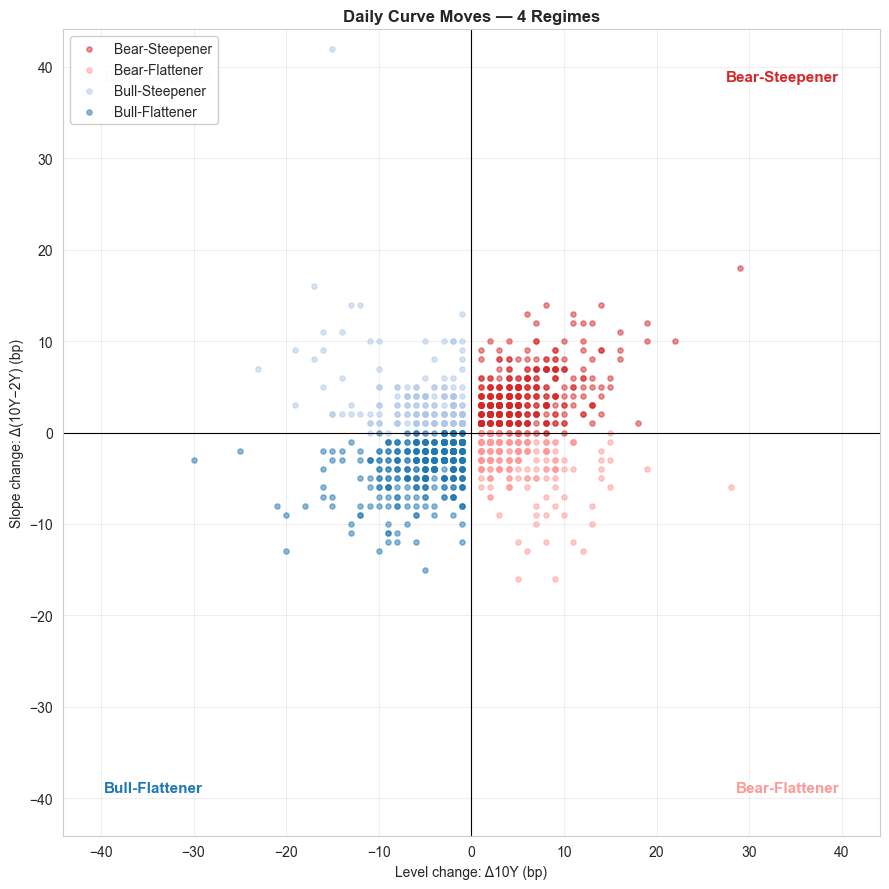

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
for label, color in REGIME_COLORS.items():
    mask = regime == label
    ax.scatter(level_change[mask], slope_change[mask],
               s=14, alpha=0.5, color=color, label=label)

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
lim = max(abs(level_change).max(), abs(slope_change).max()) * 1.05
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("Level change: Δ10Y (bp)")
ax.set_ylabel("Slope change: Δ(10Y−2Y) (bp)")
ax.set_title("Daily Curve Moves — 4 Regimes")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)

# 象限ラベル
ax.text(0.95, 0.95, "Bear-Steepener", transform=ax.transAxes,
        ha="right", va="top", fontsize=11, weight="bold", color=REGIME_COLORS["Bear-Steepener"])
ax.text(0.95, 0.05, "Bear-Flattener", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=11, weight="bold", color=REGIME_COLORS["Bear-Flattener"])
ax.text(0.05, 0.95, "Bull-Steepener", transform=ax.transAxes,
        ha="left", va="top", fontsize=11, weight="bold", color=REGIME_COLORS["Bull-Steepener"])
ax.text(0.05, 0.05, "Bull-Flattener", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=11, weight="bold", color=REGIME_COLORS["Bull-Flattener"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_regime_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- 4象限にほぼ均等に散らばっている → どのレジームも普通に発生する
- 中心付近(原点)が最も密 → ほとんどの日は小さな動き(典型的に ±5〜10bp)
- 外れ値(スキャッターの端)が **FOMC日や CPI 発表日** などのイベントデー

### 4.2 レジームの時間推移

各日のレジームを縦線で時系列にプロット。**色の塊**がそのままマーケット局面を示す。

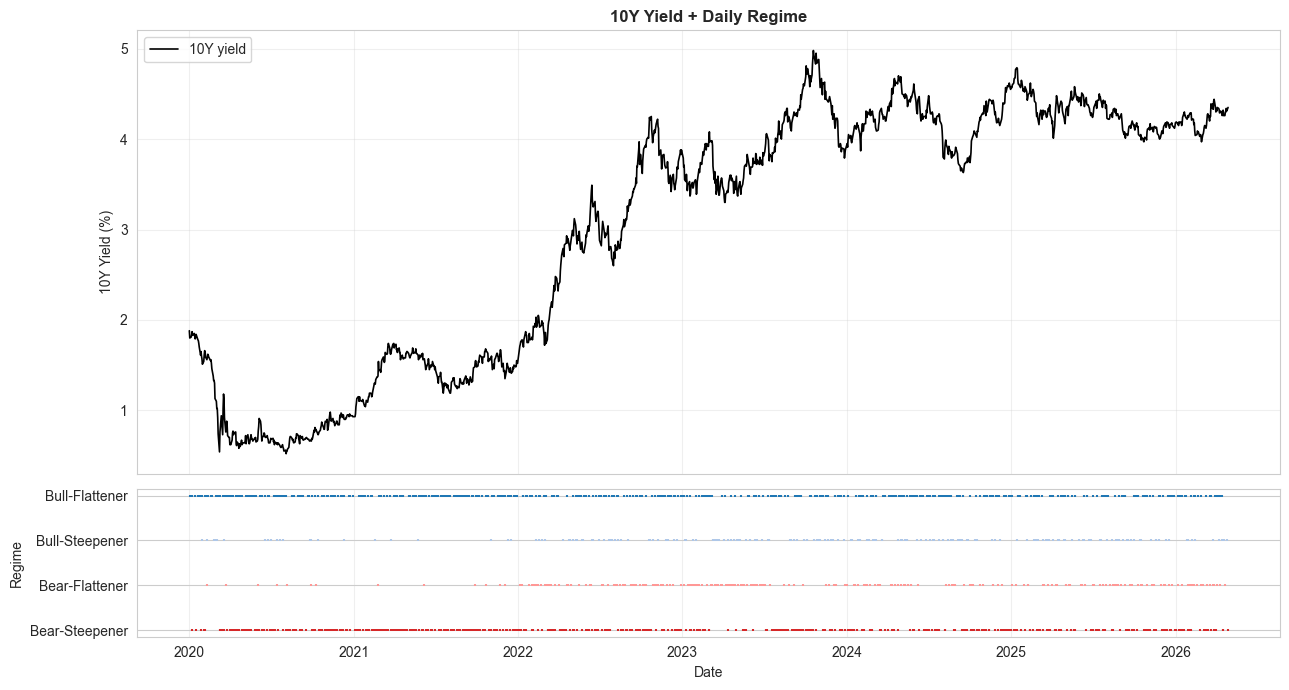

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

# 上: 10Y 利回りの推移
axes[0].plot(yields.index, yields["10Y"], color="black", lw=1.2, label="10Y yield")
axes[0].set_ylabel("10Y Yield (%)")
axes[0].set_title("10Y Yield + Daily Regime")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

# 下: レジームの帯
y_pos = {label: i for i, label in enumerate(REGIME_COLORS.keys())}
for label, color in REGIME_COLORS.items():
    mask = regime == label
    axes[1].scatter(regime.index[mask], [y_pos[label]] * mask.sum(),
                    color=color, s=4, marker="|")
axes[1].set_yticks(list(y_pos.values()))
axes[1].set_yticklabels(list(y_pos.keys()))
axes[1].set_ylabel("Regime")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_regime_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.3 各レジームの構成比

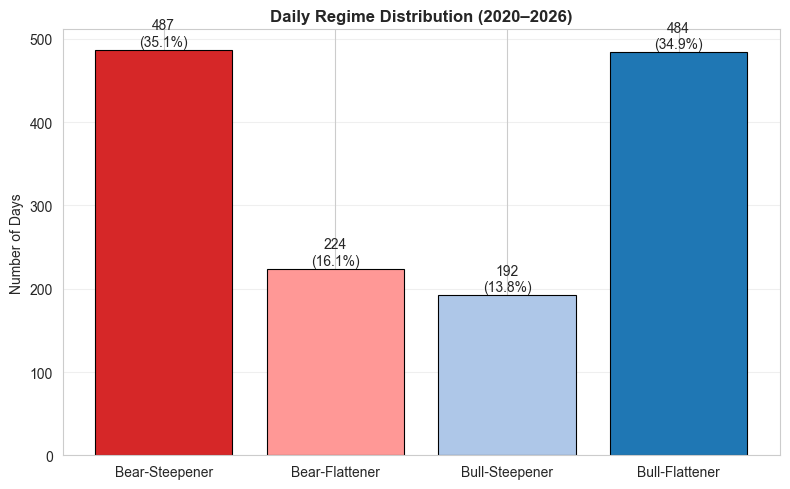

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ordered = ["Bear-Steepener", "Bear-Flattener", "Bull-Steepener", "Bull-Flattener"]
counts = [regime_counts.get(r, 0) for r in ordered]
colors = [REGIME_COLORS[r] for r in ordered]

bars = ax.bar(ordered, counts, color=colors, edgecolor="black", lw=0.8)
for bar, count in zip(bars, counts):
    pct = count / sum(counts) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{count}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Number of Days")
ax.set_title("Daily Regime Distribution (2020–2026)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_regime_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**観察**:
- **Bear-Steepener と Bull-Flattener が最多(各 31%、合計 62%)** = 「**長期金利が短期金利より大きく動いた日**」
  - 日々のタームプレミアムやインフレ期待の変動が長期側に効くため
- **Bear-Flattener と Bull-Steepener は少ない(各 12〜14%、合計 26%)** = 「**短期金利が長期金利より大きく動いた日**」
  - これらは典型的に FOMC 日 / CPI 発表日など、**政策見通しが大きく動いたイベント**
- **教訓**: 普段は長期側がノイジー、特別な日は短期側がドラマチックに動く
- これが PCA で PC1(全体水準)と PC2(スロープ)に分解される根拠の1つ

## 5. 派生計算: 後の Notebook で使うので保存しておく

`changes_bp` は Notebook 03(PCA)で直接使う。**parquet で永続化**しておくと、
再計算せずに済む。

In [12]:
changes_bp.to_parquet(DATA_PROCESSED / "ust_yields_changes_bp.parquet")
print(f"Saved: {DATA_PROCESSED / 'ust_yields_changes_bp.parquet'}")

regime.to_frame("regime").to_parquet(DATA_PROCESSED / "daily_regime.parquet")
print(f"Saved: {DATA_PROCESSED / 'daily_regime.parquet'}")

slopes.to_parquet(DATA_PROCESSED / "slopes.parquet")
print(f"Saved: {DATA_PROCESSED / 'slopes.parquet'}")

Saved: C:\FICC\data\processed\ust_yields_changes_bp.parquet
Saved: C:\FICC\data\processed\daily_regime.parquet
Saved: C:\FICC\data\processed\slopes.parquet


## 6. まとめ

### この Notebook で達成したこと
- ✅ 月次スナップショットでカーブの**形の変化**を一望(色 = 時間)
- ✅ 日次変化を **bp 単位**で計算、典型的に **±10bp 範囲内**(95%レベル)を確認
- ✅ ヒートマップで個別イベントの動きの**性格**(Level vs Slope)を視覚化
- ✅ 3種類のスロープ指標(2s10s, 5s30s, 3M2Y)を比較
- ✅ **ベア/ブル × スティープ/フラット 4分類**を実装、各日に分類を付与

### 重要な発見
- **カーブの動きは Level + Slope の2次元でほぼ説明できそう** ← Notebook 03 への伏線
- **短期と長期で動きの性格が違う**: 短期は政策連動、長期はイベント反応
- **2022〜2024年の逆イールド**は3つのスロープすべてでマイナス確認(歴史的事象)

### Notebook 03 へのつなぎ
ここまでで Level と Slope を「**人間が決めた指標**」(10Y、2s10s)で分析した。
次は **PCA がデータから自動でこれを発見する**ことを確認する。

PC1 は Level、PC2 は Slope と**ほぼ同じもの**になるはず —— という仮説を検証する。